# 01.Sankey

In [2]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from collections import defaultdict
import itertools
import seaborn as sns

colors = sns.color_palette("deep", n_colors=10)

diag_col = 'Mass_Spect_Diagnosis_SK_New'

if diag_col == 'Mass_Spect_Diagnosis_SK_New':
    diagnosis_order = ['MGUS', 'P-CH', 'Low peak', 'Negative']

    hex_colors = [f"#{int(color[0]*255):02X}{int(color[1]*255):02X}{int(color[2]*255):02X}" for color in colors]
    node_colors_dict = {
        'Negative': hex_colors[0], 
        'Low peak': hex_colors[2], 
        'P-CH': hex_colors[1], 
        'MGUS': hex_colors[3],
        'Others' : 'lightgray',
    }
    
    alpha = 0.5 
    hex_colors_with_alpha = [
        f"rgba({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)},{alpha})" 
        for color in colors
    ]
    
    link_colors_dict = {
        'Negative': hex_colors_with_alpha[0], 
        'Low peak': hex_colors_with_alpha[2], 
        'P-CH': hex_colors_with_alpha[1], 
        'MGUS': hex_colors_with_alpha[3],
        'Others' : 'lightgray'
    }
    

filt_reshaped2_indv = pd.read_csv('../data/PROMISE_ms_indv.csv', sep=",")
filt_reshaped2_indv[diag_col] = filt_reshaped2_indv[diag_col].replace('MGIP', 'P-CH')

##### follow-up number distribution
max_timepoint_dist = (
    filt_reshaped2_indv
    .groupby('PROMISE_ID')['timepoint']
    .max()
    .value_counts()
    .sort_index()
)

print(max_timepoint_dist)

timept = 'timepoint2'
#timept = 'timepoint'

filt_reshaped2_indv_timept = filt_reshaped2_indv.dropna(subset=timept)

# Calculate interval years for each patient
filt_reshaped2_indv_timept['Yrs_interval'] = abs(
    filt_reshaped2_indv_timept
    .sort_values(['PROMISE_ID', timept], ascending=False)  
    .groupby('PROMISE_ID')['yrs_from_baseline']
    .diff()
)

# at baseline
timept_1 = filt_reshaped2_indv_timept[filt_reshaped2_indv_timept[timept] == 1.0]

stats = timept_1.groupby(diag_col)['Yrs_interval'].agg(
    median=lambda x: f"{x.median():.2f}",
    min=lambda x: f"{x.min():.2f}",
    max=lambda x: f"{x.max():.2f}",
    perc_25=lambda x: f"{x.quantile(0.25):.2f}",
    perc_75=lambda x: f"{x.quantile(0.75):.2f}",
).reset_index()

print('**** Median time to subsequent sample collection (Negative inclues MSL [no m/z ratio], <LLMI, LC only) ****')
print(stats)


grouped = filt_reshaped2_indv_timept.groupby(['PROMISE_ID', timept, diag_col]).size().reset_index(name='count')


def timepoint_comparisons(df):
    timepoints_c = sorted(df[timept].unique())
    results = []

    for tp1, tp2 in itertools.combinations(timepoints_c, 2):
        df_tp1 = df[df[timept] == tp1]
        df_tp2 = df[df[timept] == tp2]

        for diag1 in df_tp1[diag_col].unique():
            for diag2 in df_tp2[diag_col].unique():
                count = len(pd.merge(df_tp1[df_tp1[diag_col] == diag1],
                                     df_tp2[df_tp2[diag_col] == diag2],
                                     on='PROMISE_ID', how='inner'))
                if count > 0:
                    results.append({'tp1': tp1, 'MS1': diag1,
                                    'tp2': tp2, 'MS2': diag2, 'Count': count})

    return pd.DataFrame(results)


df = timepoint_comparisons(grouped)
df.reset_index(drop=True)
df = df[['MS1', 'MS2', 'Count']]

# Print % 
total_counts_ms1 = df.groupby('MS1')['Count'].sum()

df['percentage'] = df.apply(
    lambda row: (row['Count'] / total_counts_ms1[row['MS1']]) * 100,
    axis=1
)

print(df.groupby(['MS1']).sum())
print(df.groupby(['MS2']).sum())
print("Percentage of how many x in MS1 unique become y in MS2:")
for i, row in df.iterrows():
    print(f"{row['MS1']} -> {row['MS2']} : {row['percentage']:.2f}%")

negative_starts = df[df['MS1'] == 'Negative']
print("**** Outcome of patients who started as Negative ****")
print(negative_starts[['MS2', 'Count', 'percentage']])

colors = sns.color_palette("deep", n_colors=4)

replace_dict = {val: i for i, val in enumerate(diagnosis_order)}

source = df['MS1'].map(replace_dict)
target = df['MS2'].map(replace_dict) + len(diagnosis_order)
values = df['Count']
timepoints = len(filt_reshaped2_indv[timept].unique())

# Prepare Sankey diagram inputs
categories = diagnosis_order 
labels = diagnosis_order

link_colors = [
    link_colors_dict[df['MS1'].iloc[i]] for i in range(len(df))
]

n_categories = len(diagnosis_order)
x_coords = [0.1] * n_categories + [0.9] * n_categories
y_coords = [i / (n_categories - 1) for i in range(n_categories)] * 2

# Create Sankey diagram
fig = go.Figure(
    data = [
        go.Sankey(
            node=dict(
                pad=0, 
                thickness=30, 
                line=dict(color="black", width=0.5),
                label=labels * timepoints,
                color=[node_colors_dict[cat] for cat in categories] * timepoints,
                x = x_coords,
                y = y_coords
            ),
            link=dict(
                source=source,
                target=target,
                value=values,
                color=link_colors
            ),
            arrangement='snap',
)])


fig.update_layout(
    width=500,
    font_size=14,
)

fig.write_image(f"../00.Figures/PROMISE_MS_dig_prevalence_sankey_New.pdf", engine="kaleido")
fig.show()


2     1044
3      140
4       45
5       20
6       12
7        4
8        4
10       1
11       1
Name: timepoint, dtype: int64
**** Median time to subsequent sample collection (Negative inclues MSL [no m/z ratio], <LLMI, LC only) ****
  Mass_Spect_Diagnosis_SK_New median   min   max perc_25 perc_75
0                    Low peak   3.64  0.24  6.35    3.19    4.03
1                        MGUS   2.37  0.09  6.45    1.15    3.63
2                    Negative   3.77  0.01  6.64    3.43    4.01
3                        P-CH   3.31  0.13  6.64    2.54    4.49
          Count  percentage
MS1                        
Low peak    150       100.0
MGUS        165       100.0
Negative    693       100.0
P-CH        263       100.0
          Count  percentage
MS2                        
Low peak    241   78.996307
MGUS        229  118.429137
Negative    531  113.908219
P-CH        270   88.666337
Percentage of how many x in MS1 unique become y in MS2:
Negative -> Low peak : 20.06%
Negative -> Nega

/tmp/ipykernel_8057/971319142.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# 02.Transition probability (by diagnosis)

/tmp/ipykernel_12722/3655130217.py:35: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.



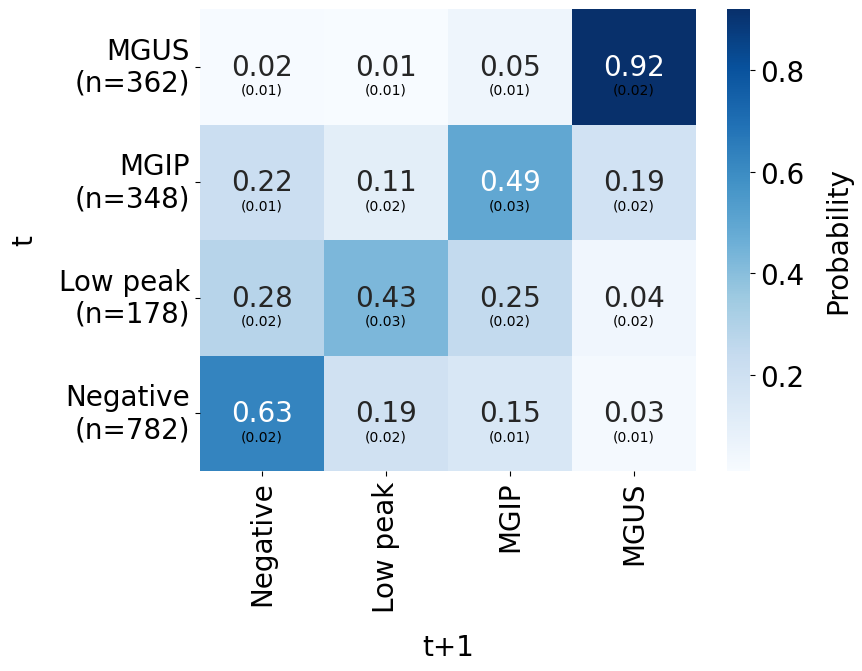

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

subj_col = 'PROMISE_ID'
date_col = 'yrs_from_baseline'
diag_col = 'Mass_Spect_Diagnosis_SK_New'

filt_reshaped2_indv = pd.read_csv('../data/PROMISE_ms_indv.csv', sep=",")

filt_reshaped2_indv[diag_col] = filt_reshaped2_indv[diag_col].replace({
    "Low_MS":"Low peak",
    "MS-MGUS" : "MGUS",
    "MSL" : "Negative",
    "LC_only" : "Negative",
    "<LLMI" : "Negative"
})
#diagnosis_order = ['MGUS', 'MGIP', 'Low MG', 'Others', 'Negative']
diagnosis_order = ['MGUS', 'MGIP', 'Low peak', 'Negative']

df = filt_reshaped2_indv[[subj_col, date_col, diag_col]]
df = df.sort_values(by=[subj_col, date_col])
df['Next_State'] = df.groupby(subj_col)[diag_col].shift(-1)
df['interval'] = (df[date_col] - df.groupby(subj_col)[date_col].shift(-1)).abs()
transitions = df.dropna(subset=['Next_State'])

transition_counts = transitions.groupby([diag_col, 'Next_State']).size().unstack(fill_value=0)
transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)

transition_probabilities = transition_probabilities.loc[diagnosis_order, list(reversed(diagnosis_order))]

## SE 
sample_sizes = transition_counts.sum(axis=1)
stderr_df = np.sqrt(transition_probabilities * (1 - transition_probabilities) / sample_sizes[:, None])
stderr_df = stderr_df.loc[list(reversed(diagnosis_order)), diagnosis_order]

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20})
ax = sns.heatmap(
    transition_probabilities, 
    annot=True, 
    cmap="Blues", 
    cbar_kws={'label': 'Transition probability'},
    fmt=".2f"
)

colorbar = ax.collections[0].colorbar  # Get the colorbar object
colorbar.set_label('Probability', labelpad=15)  # Set label and labelpad

y_counts = transitions.groupby(diag_col).size().reindex(transition_probabilities.columns, fill_value=0)
yticklabels = list(reversed([f"{label}\n(n={y_counts[label]})" for label in transition_probabilities.columns]))
ax.set_yticklabels(yticklabels, rotation=0)

for i in range(transition_probabilities.shape[0]):
    for j in range(transition_probabilities.shape[1]):
        prob_value = transition_probabilities.iloc[i, j]
        stderr_value = stderr_df.iloc[i, j]
        # Insert formatted error (stderr) below the value
        ax.text(
            j + 0.5,  # x position (shifted for correct placement)
            i + 0.7,  # y position (shifted for correct placement)
            f"({stderr_value:.2f})",  # Display stderr value below the probability
            ha='center', va='center', color='black', fontsize=10
        )
        
plt.xlabel("t+1", labelpad=15)
plt.ylabel("t", labelpad=15)
plt.savefig('../00.Figures/PROMISE_transition_probability_heatmap_MSdiagnosis.pdf', bbox_inches='tight')
plt.show()


# 03.Clonal dynamic pattern

In [3]:
import pandas as pd
import numpy as np
import os, glob, subprocess, itertools
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

filt_reshaped2_indv = pd.read_csv('../data/PROMISE_ms_indv.csv', sep=",")

subj_col = 'PROMISE_ID'
clone_col = "clone_id"
time_col = 'yrs_from_baseline'
diag_col = 'Mass_Spect_Diagnosis_SK_New'

### Others
filt_reshaped2_indv[diag_col] = filt_reshaped2_indv[diag_col].replace({
    "Low_MS":"Low MS",
    "MSL" : "Negative",
    "LC_only" : "Negative",
    "<LLMI" : "Negative",
    "C1q-C" : "Negative"
})

def detect_clone_shift(data, clone_col=clone_col, subject_col=subj_col, time_col=time_col):
    clone_shift_dict = {}

    for pid, grp in data.groupby(subject_col):
        grp = grp.sort_values(by=time_col, ascending=True)

        # Get the number of unique Clone_IDs for this person
        unique_clones = grp[clone_col].nunique()

        # If more than one unique Clone_ID exists, it means a shift occurred
        has_shift = unique_clones > 1

        clone_shift_dict[pid] = has_shift
    
    return clone_shift_dict

def classify_group(group):
    vals = group['clonality_group2'].dropna()
    dxs = group[diag_col].dropna()

    if vals.empty:
        if (dxs == 'Negative').all():
            return 'Negative'
        else: 
            return 'Single'
            
    if len(vals) == 1:
        return 'Transient'

    if (vals == 'Single').all():
        return 'Single'

    return 'Multiple'

data = filt_reshaped2_indv.copy()

total_number = len(data.groupby(subj_col))

### remove 'Others' (c1q-c, <llmi, msl)
data = data[data['Conc'] != 0]
data = data[data['Conc'].notna()]
data = data[~data['Flag'].isin(['<LLMI', 'MSL', 'C1q-C'])]

### remove kappa lambda
data = data[~data['Type'].isin(['Kappa', 'Lambda'])]

# Apply category
label_by_pid = (
    data
    .groupby(subj_col)
    .apply(classify_group)
    .rename('Clonality_Category')
)

data = data.merge(label_by_pid, left_on=subj_col, right_index=True)

# 1. Count per category
category_counts = label_by_pid.value_counts()

# 2. Fraction (ratio)
category_fraction = label_by_pid.value_counts(normalize=True) * 100

print("=== Category Counts ===")
print(category_counts)

########## Use Multiple ##########

multiple_data = data[data['Clonality_Category'] == 'Multiple']

# Run detection
clone_shifts = detect_clone_shift(multiple_data)

clone_shifts_true = {pid: shift for pid, shift in clone_shifts.items() if shift}

for pid, shift in clone_shifts_true.items():
    print(pid, multiple_data[multiple_data[subj_col] == pid][diag_col].tolist())

print(clone_shifts_true.keys())
#### Not many serial clones --> e.g. 13
    
# Count individuals with & without clone shifts
shift_counts = pd.Series(clone_shifts).value_counts()


# Get median years (1st timepoint) of each groups
time_stats = {}

# Step 1: Get individual groups
classical_ids = list(set(data[data['Clonality_Category'] == 'Single'][subj_col].tolist()))
clonal_dom_ids = [pid for pid, shift in clone_shifts.items() if not shift]
shifted_dom_ids = [pid for pid, shift in clone_shifts.items() if shift]

# Step 2: Define a function to get first timepoint per individual
def get_first_timepoints(data, id_list):
    first_times = []
    for pid in id_list:
        person_data = data[data[subj_col] == pid]
        if not person_data.empty:
            first_time = person_data[time_col].max()  # Largest value = earliest in time
            first_times.append(first_time)
    return first_times

# Step 3: Compute for each group
time_stats["Monoclonal persistence"] = get_first_timepoints(data, classical_ids)
time_stats["Single dominance"] = get_first_timepoints(multiple_data, clonal_dom_ids)
time_stats["Shifting Dominance"] = get_first_timepoints(multiple_data, shifted_dom_ids)


pos_number = len(data[data['Clonality_Category'].isin(['Multiple', 'Single'])].groupby(subj_col))
print(f"Total number: {total_number}, Total MS positive (>=2): {pos_number}")

# Step 4: Print stats
for group, times in time_stats.items():
    if times:
        median_val = np.median(times)
        min_val = np.min(times)
        max_val = np.max(times)
    else:
        print(f"{group}: No data available.")

    print(f"******** {group}: n={len(times)} ({len(times)/pos_number*100:.0f}%)" )
    print(f"Median yr from baseline: {median_val:.1f} ({min_val:.1f}-{max_val:.1f})")


############################ Isotype change
# Group by patient and get first/last non-negative timepoints
results = []
for pid, group in data.groupby(subj_col):
    group = group.sort_values(by=time_col, ascending=True)  # smallest first

    # Get earliest and latest timepoints
    first = group.iloc[0]
    last = group.iloc[-1]

    # Store results
    results.append({
        'id': pid,
        'first_Type_heavy': first['major_type'],
        'last_Type_heavy': last['major_type'],
        'first_yr_from_baseline': first[time_col],
        'last_yr_from_baseline': last[time_col]
    })

# Convert to DataFrame
shift_df = pd.DataFrame(results)

# Step 3: Count cases where first is IgM
igm_cases = shift_df[shift_df['first_Type_heavy'] == 'IgM']
igm_total = len(igm_cases)

# Step 4: Of those, count how many shifted to IgG or IgA
total = len(results)
igm_switched = igm_cases[igm_cases['last_Type_heavy'].isin(['IgG', 'IgA'])]
igm_switched_igg = igm_cases[igm_cases['last_Type_heavy'].isin(['IgG'])]
igm_switched_igg_count = len(igm_switched_igg)
igm_switched_iga = igm_cases[igm_cases['last_Type_heavy'].isin(['IgA'])]
igm_switched_iga_count = len(igm_switched_iga)


igm_switched_id = igm_switched['id'].tolist()

print("**************** Isotype change (IgM->IgG/A) ")
print(f"Total individuals with initial IgM: {igm_total}, {igm_total/pos_number*100:.0f}%")
print(f"Of those, number that switched to IgG: {igm_switched_igg_count}, {igm_switched_igg_count/igm_total*100:.0f}%")
print(f"Of those, number that switched to IgA: {igm_switched_iga_count}, {igm_switched_iga_count/igm_total*100:.0f}%")
print(igm_cases['id'].tolist())
print(igm_switched_id)

    

=== Category Counts ===
Transient    362
Multiple     324
Single       173
Name: Clonality_Category, dtype: int64
13 ['MGIP', 'Low peak', 'MGIP', 'Low peak']
66 ['MGIP', 'MGIP']
67 ['MGIP', 'Low peak']
72 ['MGIP', 'MGIP', 'MGIP']
139 ['MGIP', 'MGUS', 'MGIP', 'MGIP', 'MGIP']
176 ['MGIP', 'MGUS']
271 ['MGUS', 'MGIP', 'MGUS']
326 ['MGIP', 'MGIP', 'MGIP', 'MGIP', 'MGIP']
343 ['MGIP', 'MGIP']
405 ['MGIP', 'Low peak', 'MGIP']
512 ['MGIP', 'Low peak']
540 ['MGIP', 'Low peak']
543 ['MGUS', 'Low peak']
554 ['Low peak', 'Low peak']
563 ['MGIP', 'MGUS', 'MGUS', 'MGUS', 'MGUS']
659 ['MGIP', 'MGIP']
665 ['MGIP', 'MGUS', 'MGUS', 'MGUS', 'MGUS']
695 ['MGIP', 'MGIP']
736 ['MGIP', 'MGIP']
740 ['MGIP', 'MGUS']
781 ['MGIP', 'MGUS']
796 ['Low peak', 'Low peak']
801 ['MGIP', 'MGIP']
816 ['MGIP', 'MGIP', 'MGIP']
850 ['MGIP', 'MGIP', 'MGIP']
852 ['Low peak', 'MGIP']
883 ['MGIP', 'MGIP', 'MGUS']
957 ['Low peak', 'MGIP', 'Low peak']
974 ['Low peak', 'Low peak']
987 ['MGIP', 'MGIP']
1009 ['MGIP', 'MGIP', 'MGIP'

# 04.Visualize all clones + MGIP->MGUS clones

[MGIP->MS-MGUS | patient=42 | clone=42_clone3 | isotype=IgG
[MGIP->MS-MGUS | patient=180 | clone=180_clone2 | isotype=IgG
[MGIP->MS-MGUS | patient=273 | clone=273_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=315 | clone=315_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=430 | clone=430_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=552 | clone=552_clone2 | isotype=IgM
[MGIP->MS-MGUS | patient=563 | clone=563_clone5 | isotype=IgM
[MGIP->MS-MGUS | patient=640 | clone=640_clone1 | isotype=IgM
[MGIP->MS-MGUS | patient=717 | clone=717_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=927 | clone=927_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=950 | clone=950_clone1 | isotype=IgA
[MGIP->MS-MGUS | patient=950 | clone=950_clone2 | isotype=IgG
[MGIP->MS-MGUS | patient=1085 | clone=1085_clone1 | isotype=IgG
[MGIP->MS-MGUS | patient=1106 | clone=1106_clone2 | isotype=IgM
[MGIP->MS-MGUS | patient=1106 | clone=1106_clone4 | isotype=IgM
[MGIP->MS-MGUS | patient=1263 | clone=1263_clone4 | isotype=IgM
[M

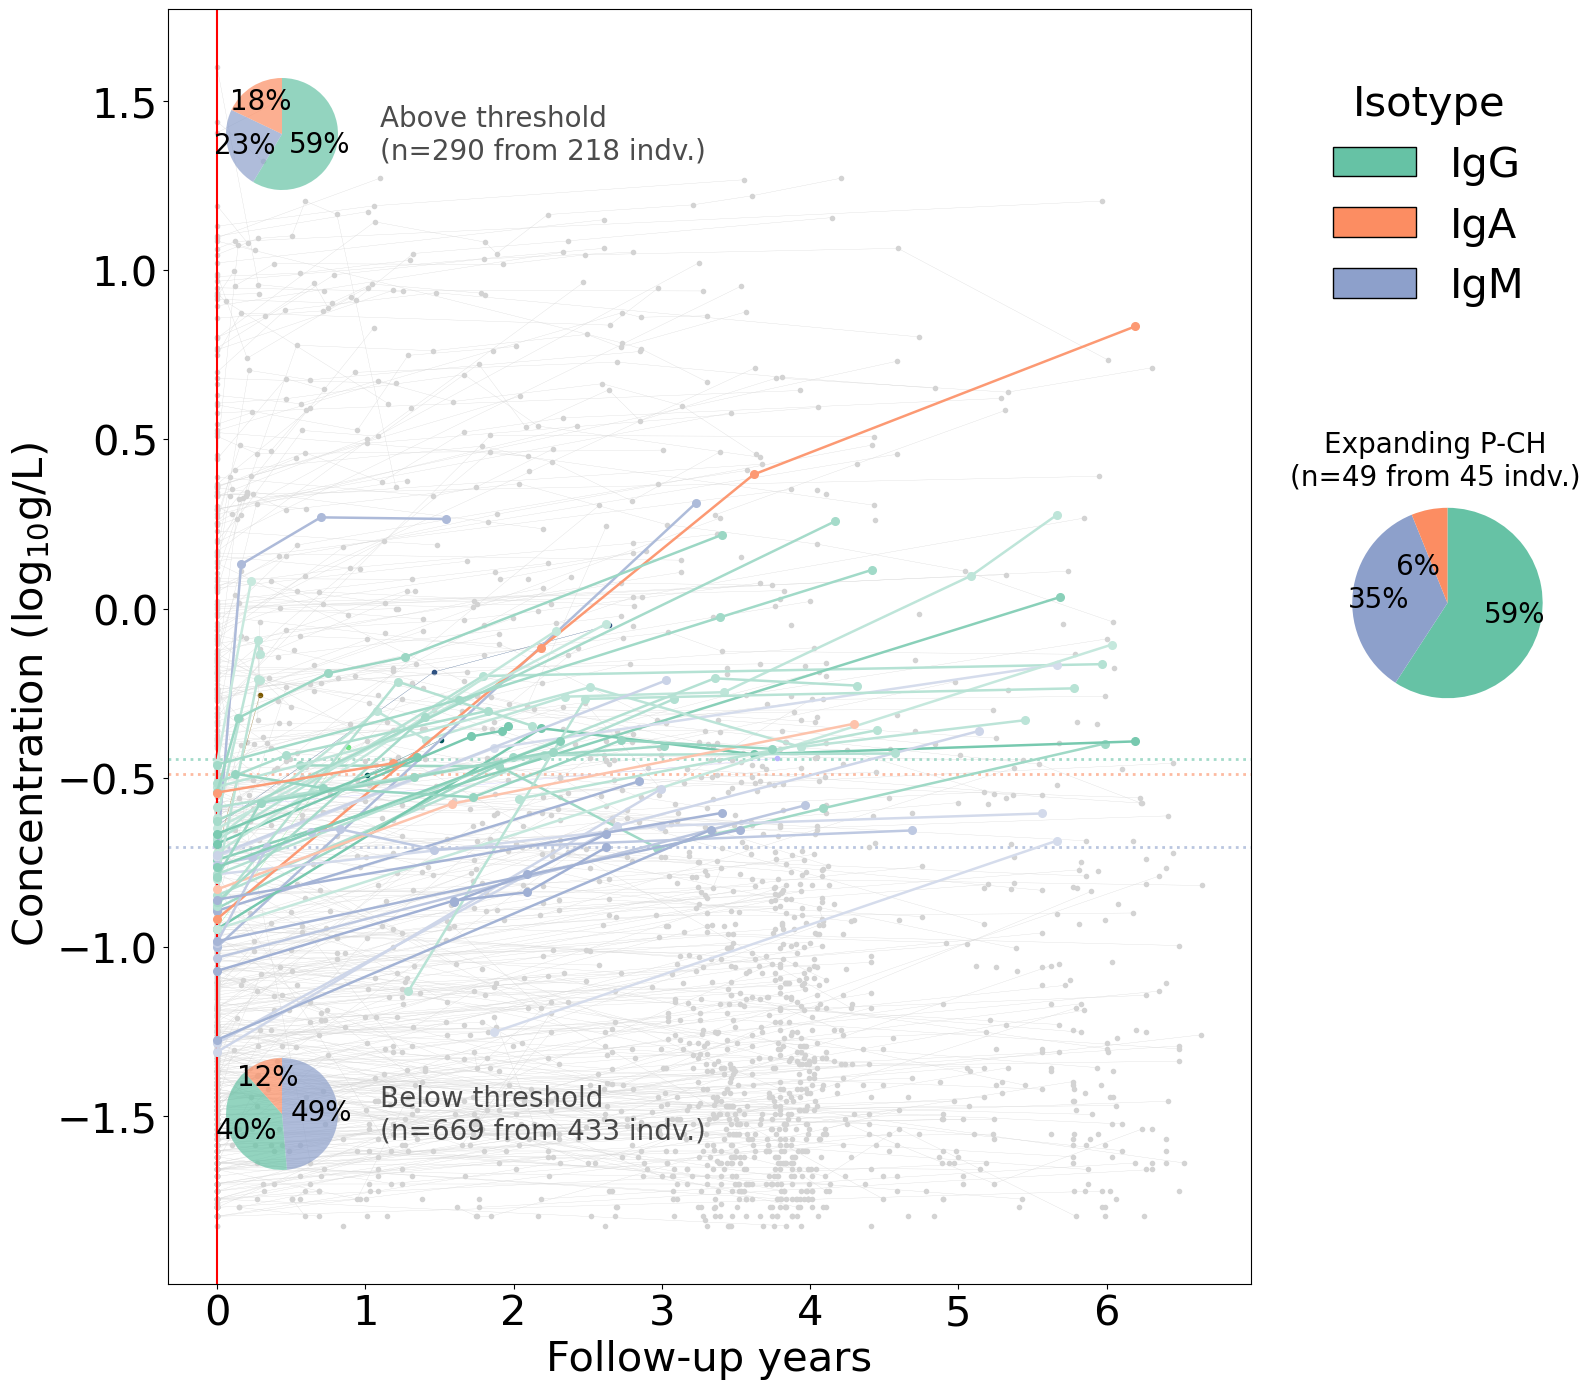

In [3]:
import matplotlib
matplotlib.colormaps._allow_override_builtin = True  
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.text import Text
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import colorcet as cc
from collections import defaultdict
import matplotlib.colors as mcolors
import colorsys

PERSON_COL = "PROMISE_ID"
DATE_COL = "Sample_Date"
TIME_COL = 'yrs_from_baseline'
CLONE_COL = "clone_id"
CONC_COL = "Conc"
ISO_COL = "Heavy_type"
MZ_COL = "m.z"
DX_COL = "Mass_Spect_Diagnosis_SK_New" #"Ghobrial_Lab_Diagnosis_BS"
AGE_COL = "Age_At_Sample"

def lighten_color(color, amount=0.5):
    """
    ligher if amount is larger (0-1)
    """
    try:
        c = mcolors.cnames[color]
    except Exception:
        c = color
    r, g, b = mcolors.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = 1 - amount * (1 - l)
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return (r2, g2, b2)

def get_log_thresh(val):
    if pd.isna(val) or val <= 0:
        return -np.inf
    return np.log10(val)

def generate_palette_from_base(base_color, n):
    """
    n * shade per same hue based on base_color
    """
    if n <= 1:
        return [base_color]

    shades = []
    amounts = np.linspace(0.35, 0.9, n)
    for a in amounts:
        shades.append(lighten_color(base_color, amount=a))
    return shades

def build_clone_color_maps(df):
    igh_colors = {
        'IgG': '#66c2a5',
        'IgA': '#fc8d62',
        'IgM': '#8da0cb',
    }

    clone_ids = sorted(df[CLONE_COL].dropna().unique())
    isotype_counts = defaultdict(int)
    clone_id_to_label = {}

    for clone_id in clone_ids:
        clone_data = df[df[CLONE_COL] == clone_id]
        unique_types = clone_data[ISO_COL].dropna().unique()

        if len(unique_types) == 0:
            label = f"Unknown {clone_id}"
        else:
            label = str(unique_types[0])

        clone_id_to_label[clone_id] = label
        iso = label.split()[0]
        isotype_counts[iso] += 1

    isotype_shades = {
        iso: generate_palette_from_base(base_color, isotype_counts[iso])
        for iso, base_color in igh_colors.items()
        if isotype_counts[iso] > 0
    }

    shade_indices = defaultdict(int)
    clone_id_to_color = {}

    for clone_id in clone_ids:
        label = clone_id_to_label[clone_id]
        iso = label.split()[0]

        if iso in isotype_shades:
            idx = shade_indices[iso]
            clone_id_to_color[clone_id] = isotype_shades[iso][idx]
            shade_indices[iso] += 1
        else:
            clone_id_to_color[clone_id] = "#999999"

    return clone_ids, clone_id_to_label, clone_id_to_color



promise_df = pd.read_csv("../data/PROMISE_ms_clone.csv", sep=",")
promise_df[DATE_COL] = pd.to_datetime(promise_df[DATE_COL], errors="coerce")

### remove 'Others' (c1q-c, <llmi, msl)
promise_df = promise_df[promise_df['Conc'] != 0]
promise_df = promise_df[promise_df['Conc'].notna()]
promise_df = promise_df[~promise_df['Flag'].isin(['<LLMI', 'MSL', 'C1q-C'])]

### remove kappa lambda
promise_df = promise_df[~promise_df['Type'].isin(['Kappa', 'Lambda'])]

filt_reshaped2 = promise_df.copy()

filt_reshaped2 = filt_reshaped2.dropna(subset=[CONC_COL])

filt_reshaped2['Conc_log10'] = np.log10(filt_reshaped2[CONC_COL])

filt_reshaped2.replace([np.inf, -np.inf], np.nan, inplace=True)

filt_reshaped2 = filt_reshaped2.dropna(subset=['Conc_log10'])

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1]) ## 2, 2

all_condition_summary = {}
transition_ybdx_all = {}

traj_font=30
pie_font=20

igh_colors = {
    'IgG': '#66c2a5',
    'IgA': '#fc8d62',  
    'IgM': '#8da0cb',
}

bs_thresh_map = {
    'IgG': 0.359,
    'IgA': 0.325,
    'IgM': 0.197,
}

mgip_thresh_map = {
    'IgG': 0.000,   # include all IgG
    'IgA': 0.070,
    'IgM': 0.044,
}


#color_palette = sns.color_palette("husl", 100)
color_palette = cc.glasbey[:100]
color_index = 0

subset = filt_reshaped2.copy()
ax_main = fig.add_subplot(gs[0, 0])
condition_summary = {"Stable MS-MGUS": [], "Stable MGIP": [], "MGIP->MS-MGUS": [], "Others": []}
transition_ybdx = []
transition_line_info = []

clone_ids_all, clone_id_to_label, clone_id_to_color = build_clone_color_maps(filt_reshaped2)

for idx, (group_key, group) in enumerate(subset.groupby([PERSON_COL, CLONE_COL])):
    patient_id, clone_id = group_key
    group = group.sort_values(TIME_COL).copy() #### time ascending
    x, y = TIME_COL, 'Conc_log10'

    isotype = group[ISO_COL].dropna().iloc[0]

    if isotype not in bs_thresh_map or isotype not in mgip_thresh_map:
        condition_summary["Others"].append(group_key)
        continue

    bs_thresh = np.log10(bs_thresh_map[isotype])
    mgip_thresh = np.log10(mgip_thresh_map[isotype]) if mgip_thresh_map[isotype] > 0 else -np.inf

    yvals = group[y]

    all_above_bs = (yvals >= bs_thresh).all()

    all_in_mgip_range = ((yvals >= mgip_thresh) & (yvals < bs_thresh)).all()

    ### FIRST MGIP & ANY CROSS BS
    #first_in_mgip_range = (yvals.iloc[0] >= mgip_thresh) and (yvals.iloc[0] < bs_thresh)
    #ever_crossed_bs = (yvals >= bs_thresh).any()  

    ### ANY MGIP & LAST CROSS BS 
    #pre_last = yvals.iloc[:-1]
    #any_in_mgip_range = ((pre_last >= mgip_thresh) & (pre_last < bs_thresh)).any()        

    ## BASELINE MGIP & LAST CROSS BS (MAKE SURE CLONE IS MS-MGUS AT LAST SAMPLE)
    baseline_mgip = (yvals.iloc[0] >= mgip_thresh) & (yvals.iloc[0] < bs_thresh)
    last_above_bs = yvals.iloc[-1] >= bs_thresh

    color = color_palette[color_index % len(color_palette)]
    color_index += 1

    if all_above_bs:
        condition = "Stable MS-MGUS"
        color = "lightgrey"
        linewidth, markersize = 0.2, 3
    elif all_in_mgip_range:
        condition = "Stable MGIP"
        color = "lightgrey"
        linewidth, markersize = 0.2, 3
    #elif first_in_mgip_range and ever_crossed_bs:
    elif baseline_mgip and last_above_bs:
        # Extract and sort timepoints
        timepoints = group['timepoint'].unique()
        timepoint_nums = sorted(timepoints) #sorted([int(re.search(r'\d+', t).group()) for t in timepoints])

        # Check for discontinuity
        is_continuous = all(timepoint_nums[i] + 1 == timepoint_nums[i + 1] for i in range(len(timepoint_nums) - 1))

        if is_continuous:
            condition = "MGIP->MS-MGUS"
            isotype = group[ISO_COL].dropna().iloc[0]   # Unify instead of Type_1
            color = clone_id_to_color.get(clone_id, igh_colors.get(isotype, 'grey'))
            linewidth, markersize = 1.8, 5.5

            y_vals = group[y].values
            ybdx_vals = group[TIME_COL].values
            for i in range(len(y_vals) - 1):
                if y_vals[i] < bs_thresh and y_vals[i+1] >= bs_thresh:
                    transition_ybdx.append(ybdx_vals[i])
                    transition_line_info.append((ybdx_vals[i], isotype))
                    break 
            print(
                f"[MGIP->MS-MGUS | patient={patient_id} | clone={clone_id} | isotype={isotype}"
            )

    else:
        condition = "Others"
        color = "lightgrey"
        linewidth, markersize = 0.2, 3

    zorder_value = 5 if condition == "MGIP->MS-MGUS" else 1

    condition_summary[condition].append({
        'patient_id': patient_id,
        'clone_id': clone_id,
        'isotype_heavy': isotype
    })

    ax_main.plot(group[x], group[y],
                 color=color, lw=linewidth,
                 marker='o', markersize=markersize,
                 zorder=zorder_value)

for iso in ['IgG', 'IgA', 'IgM']:
    bs_log = get_log_thresh(bs_thresh_map[iso])
    ax_main.axhline(
        y=bs_log,
        color=igh_colors[iso],
        linestyle=':',
        lw=2,
        alpha=0.6,
        zorder=0
    )

ax_main.axvline(x=0, color='red', linestyle='-', label='baseline')
ax_main.set_xlabel("Follow-up years", fontsize=traj_font)
ax_main.tick_params(axis='both', labelsize=traj_font)  

# PIE CHART coordinate
base_y = 0.850


cond_name_dict = {'Stable MS-MGUS' : 'Above threshold',
         'MGIP->MS-MGUS' : 'MGIP->MS-MGUS',
         'Stable MGIP' : 'Below threshold'}

for j, cond in enumerate(['Stable MS-MGUS', 'Stable MGIP']):
    df_cond = pd.DataFrame(condition_summary[cond])
    if not df_cond.empty:
        iso_counts = df_cond['isotype_heavy'].value_counts()
        labels = iso_counts.index.tolist()
        sizes = iso_counts.values.tolist()
        colors = [igh_colors.get(label, 'grey') for label in labels]
        n_clones = df_cond['clone_id'].nunique()
        n_patients = df_cond['patient_id'].nunique()

        pie_width = 0.10  
        pie_height = 0.10
        pos_x = 0.1
        pos_y = base_y - j * 0.7

        ax_pie = fig.add_axes([pos_x, pos_y, pie_width, pie_height])
        wedges, texts = ax_pie.pie(
            sizes,
            labels=None,
            colors=colors,
            startangle=90,
            counterclock=False,
            textprops={'fontsize': pie_font},
            wedgeprops={'alpha': 0.7}  # Adjust transparency
        )

        # add percent labels manually (optional)
        for w, s in zip(wedges, sizes):
            ang = (w.theta2 + w.theta1) / 2
            x = 0.7 * np.cos(np.deg2rad(ang))
            y = 0.7 * np.sin(np.deg2rad(ang))
            ax_pie.text(x, y, f"{s / sum(sizes) * 100:.0f}%", ha='center', va='center', fontsize=pie_font)

        ax_pie.text(1.2, 0.5,
                    f"{cond_name_dict[cond]}\n(n={n_clones} from {n_patients} indv.)",
                    transform=ax_pie.transAxes,
                    fontsize=pie_font,  alpha=0.7,
                    va='center', ha='left')

# MGIP->MS-MGUS Pie Chart
df_mid = pd.DataFrame(condition_summary['MGIP->MS-MGUS'])
if not df_mid.empty:
    iso_counts = df_mid['isotype_heavy'].value_counts()
    labels = iso_counts.index.tolist()
    sizes = iso_counts.values.tolist()
    colors = [igh_colors.get(label, 'grey') for label in labels]
    n_clones = df_mid['clone_id'].nunique()
    n_patients = df_mid['patient_id'].nunique()

    # get ax_main's position and calculate center Y
    plt.draw()
    main_pos = ax_main.get_position()
    pie_width = 0.17
    pie_height = 0.17

    center_y = main_pos.y0 + (main_pos.height / 2) + 0.07

    left_x = main_pos.x1 + 0.14  # a bit to the right of ax_main

    ax_pie_mid = fig.add_axes([left_x, center_y - pie_height / 2, pie_width, pie_height])

    ax_pie_mid.pie(
        sizes,
        labels=[f'{size / sum(sizes) * 100:.0f}%' for label, size in zip(labels, sizes)],
        colors=colors,
        startangle=90,
        counterclock=False,
        labeldistance = 0.4,
        textprops={'fontsize': pie_font}
    )
    ax_pie_mid.text(0.45, 1.1,
                    f"Expanding P-CH\n(n={n_clones} from {n_patients} indv.)",
                    transform=ax_pie_mid.transAxes,
                    fontsize=pie_font,
                    va='center', ha='center')

#all_condition_summary[disease_name] = condition_summary
#transition_ybdx_all[disease_name] = transition_ybdx

# Y-axis
fig.text(-0.02, 0.5, 'Concentration (log$_{10}$g/L)', fontsize=traj_font, va='center', 
         rotation='vertical')
## Group
bbox_style = dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4', 
                  linewidth=1.2)


# Isotype legend
legend_elements = [
    Patch(facecolor=igh_colors['IgG'], edgecolor='black', label='IgG'),
    Patch(facecolor=igh_colors['IgA'], edgecolor='black', label='IgA'),
    Patch(facecolor=igh_colors['IgM'], edgecolor='black', label='IgM'),
]

fig.legend(
    handles=legend_elements,
    title="Isotype",
    title_fontsize=traj_font,
    fontsize=traj_font,
    loc='lower right',
    bbox_to_anchor=(0.95, 0.75), 
    frameon=False
)

plt.tight_layout()
plt.savefig("../00.Figures/PROMISE_clone_MGIP_progressor_clones.pdf", bbox_inches='tight')
plt.show()


# 05.MGIP->MGUS (Above BS threshold) cases

In [5]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter
from matplotlib.colors import LinearSegmentedColormap, to_rgb, to_hex
from matplotlib.lines import Line2D
import colorsys

# =========================================================
# Configuration
# =========================================================
PERSON_COL = "PROMISE_ID"
DATE_COL = "Sample_Date"
CLONE_COL = "clone_id"
CONC_COL = "Conc"
ISO_COL = "Heavy_type"
MZ_COL = "m.z"
DX_COL = "Mass_Spect_Diagnosis_SK_New" #"Ghobrial_Lab_Diagnosis_BS"
AGE_COL = "Age_At_Sample"

BS_THRESH = {
    "IgG": 0.359,
    "IgA": 0.325,
    "IgM": 0.197,
}

MGIP_THRESH_MAP = {
    'IgG': 0.000,   # include all IgG
    'IgA': 0.071,
    'IgM': 0.044,
}


AGE_BINS = [0, 40, 50, 60, 70, 80, 120]
AGE_LABELS = ["<40", "40-50", "50-60", "60-70", "70-80", "80+"]


# =========================================================
# Helpers
# =========================================================
def get_bs_threshold(heavy_type, default=np.nan):
    heavy_type = str(heavy_type)
    for iso, thr in BS_THRESH.items():
        if iso in heavy_type:
            return thr
    return default

def get_mgip_threshold(heavy_type, default=np.nan):
    heavy_type = str(heavy_type)
    for iso, thr in MGIP_THRESH_MAP.items():
        if iso in heavy_type:
            return thr
    return default

def is_positive_diagnosis(val):
    if pd.isna(val):
        return False  
    exclude_list = ['Negative', 'LC_only', '<LLMI', 'MSL']     
    if val in exclude_list:
        return False
    return True

# Mass_Spect_Diagnosis_SK_New ['Low_MS', 'Negative', 'MSL', 'MGIP', 'LC_only', 'MS-MGUS', '<LLMI']


def summarize_followup_by_person(df):
    x = df[[PERSON_COL, DATE_COL]].copy()
    x[DATE_COL] = pd.to_datetime(x[DATE_COL], errors="coerce")
    x = x.dropna(subset=[PERSON_COL, DATE_COL])

    fu = (
        x.groupby(PERSON_COL)[DATE_COL]
        .agg(first_date="min", last_date="max", n_timepoints="nunique")
        .reset_index()
    )
    fu["followup_years"] = (fu["last_date"] - fu["first_date"]).dt.days / 365.25
    return fu


def get_baseline_rows_per_person(df): ## Major clone
    x = df.copy()
    x[DATE_COL] = pd.to_datetime(x[DATE_COL], errors="coerce")
    x[CONC_COL] = pd.to_numeric(x[CONC_COL], errors="coerce")
    
    x = x.dropna(subset=[PERSON_COL, DATE_COL, CONC_COL])
    
    x['min_date'] = x.groupby(PERSON_COL)[DATE_COL].transform('min')
    
    baseline_candidates = x[x[DATE_COL] == x['min_date']]
    
    baseline_major = baseline_candidates.loc[
        baseline_candidates.groupby(PERSON_COL)[CONC_COL].idxmax()
    ]
    
    return baseline_major.reset_index(drop=True)


def build_serial_df(df):
    x = df.copy()
    x[DATE_COL] = pd.to_datetime(x[DATE_COL], errors="coerce")
    x[CONC_COL] = pd.to_numeric(x[CONC_COL], errors="coerce")

    # clone analysis only
    x = x[x[MZ_COL] > 0].copy()
    x = x.dropna(subset=[PERSON_COL, CLONE_COL, DATE_COL, CONC_COL, ISO_COL]).copy()
    x = x.sort_values([PERSON_COL, CLONE_COL, DATE_COL]).reset_index(drop=True)

    # serial clones only
    x = (
        x.groupby([PERSON_COL, CLONE_COL], group_keys=False)
        .filter(lambda g: g[DATE_COL].nunique() >= 2)
        .copy()
    )

    # optional: remove 0 conc
    x = x[x[CONC_COL] != 0].copy()

    return x


def build_baseline_clone_table(serial_df):
    base = (
        serial_df.groupby([PERSON_COL, CLONE_COL], as_index=False)
        .first()
        .rename(columns={
            DATE_COL: "baseline_date",
            CONC_COL: "baseline_conc",
            ISO_COL: "Type_heavy",
            AGE_COL: "baseline_age",
        })
    )

    base["bs_thresh_base"] = base["Type_heavy"].apply(get_bs_threshold)
    base["mgip_thresh_base"] = base["Type_heavy"].apply(get_mgip_threshold)

    base["is_baseline_mgip"] = (
        (base["baseline_conc"] >= base["mgip_thresh_base"]) &
        (base["bs_thresh_base"].notna()) &
        (base["baseline_conc"] < base["bs_thresh_base"])
    )
    return base


def prepare_baseline_and_events(serial_df, baseline_df):
    mgip_base = baseline_df[baseline_df["is_baseline_mgip"]].copy()

    d2 = serial_df.merge(
        mgip_base[
            [
                PERSON_COL, CLONE_COL,
                "baseline_date", "baseline_conc", "Type_heavy",
                "baseline_age", "bs_thresh_base", "mgip_thresh_base"
            ]
        ],
        on=[PERSON_COL, CLONE_COL],
        how="inner"
    ).copy()

    d2 = d2.sort_values([PERSON_COL, CLONE_COL, DATE_COL]).copy()

    rows = []
    
    for (person_id, clone_id), g in d2.groupby([PERSON_COL, CLONE_COL]):
        g = g.sort_values(DATE_COL).copy()

        bs_thresh = g["bs_thresh_base"].iloc[0]
        mgip_thresh = g["mgip_thresh_base"].iloc[0]
        conc = g[CONC_COL].astype(float)

        baseline_in_mgip = (conc.iloc[0] >= mgip_thresh) and (conc.iloc[0] < bs_thresh)
        last_above_bs = conc.iloc[-1] >= bs_thresh

        timepoints = g["timepoint"].dropna().unique()
        timepoint_nums = sorted(timepoints)
        is_continuous = all(
            timepoint_nums[i] + 1 == timepoint_nums[i + 1]
            for i in range(len(timepoint_nums) - 1)
        )

        event_cross = int(baseline_in_mgip and last_above_bs and is_continuous)

        cross_date = pd.NaT
        cross_conc = np.nan

        if event_cross == 1:
            conc_vals = conc.values
            date_vals = g[DATE_COL].values
            for i in range(len(conc_vals) - 1):
                if conc_vals[i] < bs_thresh and conc_vals[i + 1] >= bs_thresh:
                    cross_date = pd.to_datetime(date_vals[i + 1])
                    cross_conc = conc_vals[i + 1]
                    break

        row0 = g.iloc[0]
        rows.append({
            PERSON_COL: person_id,
            CLONE_COL: clone_id,
            "baseline_date": row0["baseline_date"],
            "baseline_conc": row0["baseline_conc"],
            "Type_heavy": row0["Type_heavy"],
            "baseline_age": row0["baseline_age"],
            "bs_thresh_base": bs_thresh,
            "mgip_thresh_base": mgip_thresh,
            "cross_date": cross_date,
            "cross_conc": cross_conc,
            "event_cross": event_cross
        })

    out = pd.DataFrame(rows)
    out["t_years_to_cross"] = (out["cross_date"] - out["baseline_date"]).dt.days / 365.25
    return out


def build_increased_df(serial_df, baseline_mgip_events):
    event_clones = baseline_mgip_events[
        baseline_mgip_events["event_cross"] == 1
    ][[
        PERSON_COL, CLONE_COL,
        "baseline_date", "baseline_conc", "Type_heavy",
        "baseline_age", "bs_thresh_base",
        "cross_date", "cross_conc", "t_years_to_cross"
    ]].copy()

    increased_df = serial_df.merge(
        event_clones,
        on=[PERSON_COL, CLONE_COL],
        how="inner"
    ).copy()

    increased_df["Progression_Label"] = "MGIP->MGUS"
    increased_df["is_baseline_row"] = increased_df[DATE_COL] == increased_df["baseline_date"]
    increased_df["is_cross_row"] = increased_df[DATE_COL] == increased_df["cross_date"]

    return increased_df


def summarize_progression(baseline_mgip_events_df):
    df = baseline_mgip_events_df.copy()

    # clone-level
    n_clones = df.shape[0]
    n_clones_cross = int(df["event_cross"].sum())
    frac_clones_cross = n_clones_cross / n_clones if n_clones else np.nan

    # person-level
    person_any = df.groupby(PERSON_COL)["event_cross"].max()
    n_people = int(person_any.shape[0])
    n_people_cross = int(person_any.sum())
    frac_people_cross = n_people_cross / n_people if n_people else np.nan

    print("Baseline MGIP -> BS-threshold crossing summary")
    print(f"- Baseline MGIP clones: {n_clones}")
    print(f"- Clones that crossed BS threshold: {n_clones_cross} ({frac_clones_cross:.1%})")
    print(f"- Individuals with baseline MGIP clone(s): {n_people}")
    print(f"- Individuals with any crossing event: {n_people_cross} ({frac_people_cross:.1%})")

    event_df = df[df["event_cross"] == 1].copy()

    by_iso_conc = (
        event_df.groupby("Type_heavy")["baseline_conc"]
        .agg(
            n="count",
            median=lambda s: float(np.nanmedian(s)),
            mean="mean",
            p25=lambda s: float(np.nanpercentile(s, 25)),
            p75=lambda s: float(np.nanpercentile(s, 75)),
        )
        .reset_index()
        .sort_values("n", ascending=False)
    )
    by_iso_conc[["median", "mean", "p25", "p75"]] = by_iso_conc[["median", "mean", "p25", "p75"]].round(3)

    by_iso_time = (
        event_df.groupby("Type_heavy")["t_years_to_cross"]
        .agg(
            n="count",
            median="median",
            mean="mean",
            p25=lambda s: float(np.nanpercentile(s.dropna(), 25)) if s.dropna().shape[0] else np.nan,
            p75=lambda s: float(np.nanpercentile(s.dropna(), 75)) if s.dropna().shape[0] else np.nan,
        )
        .reset_index()
        .sort_values("n", ascending=False)
    )
    by_iso_time[["median", "mean", "p25", "p75"]] = by_iso_time[["median", "mean", "p25", "p75"]].round(2)

    print("\nBaseline concentration among event clones (by isotype):")
    display(by_iso_conc)

    print("\nTime-to-cross among event clones (years, by isotype):")
    display(by_iso_time)

    return by_iso_conc, by_iso_time


def calculate_followup_for_baseline_mgip(df, baseline_events_df):
    df = df.copy()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])

    fu = (
        df.groupby(PERSON_COL)[DATE_COL]
        .agg(["min", "max"])
        .reset_index()
    )
    fu["followup_years"] = (fu["max"] - fu["min"]).dt.days / 365.25

    mgip_people = baseline_events_df[PERSON_COL].unique()
    fu_mgip = fu[fu[PERSON_COL].isin(mgip_people)].copy()

    print("Baseline MGIP individuals follow-up:")
    print(f"  N individuals: {fu_mgip.shape[0]}")
    print(f"  Median follow-up: {fu_mgip['followup_years'].median():.2f} years")
    print(f"  Min follow-up:    {fu_mgip['followup_years'].min():.2f} years")
    print(f"  Max follow-up:    {fu_mgip['followup_years'].max():.2f} years")

    person_event = (
        baseline_events_df.groupby(PERSON_COL)["event_cross"]
        .max()
        .reset_index()
    )

    fu_mgip = fu_mgip.merge(person_event, on=PERSON_COL, how="left")

    print("\nEvent vs Non-event follow-up:")
    summary = (
        fu_mgip.groupby("event_cross")["followup_years"]
        .agg(["count", "median", "min", "max", "mean"])
        .reset_index()
    )
    print(summary)

    event_times = baseline_events_df[baseline_events_df["event_cross"] == 1]["t_years_to_cross"].dropna()

    if len(event_times) > 0:
        print("\nTime to crossing (event clones):")
        print(f"  Median: {event_times.median():.2f} years")
        print(f"  Min:    {event_times.min():.2f} years")
        print(f"  Max:    {event_times.max():.2f} years")

    return fu_mgip

promise_df = pd.read_csv("../data/PROMISE_ms_clone.csv", sep=",")
promise_df[DATE_COL] = pd.to_datetime(promise_df[DATE_COL], errors="coerce")

# =========================================================
# 1) TOTAL participants + follow-up
# =========================================================
overall_fu = summarize_followup_by_person(promise_df)

n_total = overall_fu[PERSON_COL].nunique()
median_fu = overall_fu["followup_years"].median()
min_fu = overall_fu["followup_years"].min()
max_fu = overall_fu["followup_years"].max()
n_total_samples = len(promise_df)

print(f"========== Total PROMISE_ID (everyone has >= 2 serial samples; {n_total_samples}): {n_total} ==========\n")
print("========== Total Follow-up ==========")
print(f"Median: {median_fu:.2f} years (min: {min_fu:.2f}, max: {max_fu:.2f}) \n")


# =========================================================
# 2) baseline positive participants (only LOW MS, MGIP, MS-MGUS)
# =========================================================
baseline_person_df = get_baseline_rows_per_person(promise_df)
baseline_person_df["baseline_positive"] = baseline_person_df[DX_COL].apply(is_positive_diagnosis)

baseline_positive_people = baseline_person_df.loc[
    baseline_person_df["baseline_positive"] == True, PERSON_COL
].unique()

baseline_positive_fu = overall_fu[overall_fu[PERSON_COL].isin(baseline_positive_people)].copy()

print("========== Baseline positive participants (without LC-only, artifiact, Negative) ==========")
print(f"N participants: {len(baseline_positive_people)}")
print(
    f"Median follow-up: {baseline_positive_fu['followup_years'].median():.2f} years "
    f"(min: {baseline_positive_fu['followup_years'].min():.2f}, "
    f"max: {baseline_positive_fu['followup_years'].max():.2f})\n"
)

# =========================================================
# 3) MGIP clone/event analysis
# =========================================================
serial_df = build_serial_df(promise_df)

baseline_df = build_baseline_clone_table(serial_df)

baseline_mgip_events = prepare_baseline_and_events(serial_df, baseline_df)

increased_df = build_increased_df(serial_df, baseline_mgip_events)

print("==== How many MGIP clones ====\n")
by_iso_conc, by_iso_time = summarize_progression(baseline_mgip_events)

fu_mgip = calculate_followup_for_baseline_mgip(
    serial_df,
    baseline_mgip_events
)

n_inc_pts = increased_df[PERSON_COL].drop_duplicates().tolist()
print(f'========== PROMISE pts with increasing MS clones: {len(n_inc_pts)}==========\n')
print(n_inc_pts)
print("** Race distribution")
race_subset = promise_df[promise_df['PROMISE_ID'].isin(n_inc_pts)]
print(race_subset['Race'].value_counts())


# =========================================================
# Age Distribution Table (Pts with MGIP->MGUS)
# participant-level age table using baseline_age from event clones
# =========================================================
inc_age_df = (
    increased_df.sort_values([PERSON_COL, "baseline_date"])
    .groupby(PERSON_COL, as_index=False)
    .first()[[PERSON_COL, "baseline_age"]]
    .copy()
)

inc_age_df["age_bin"] = pd.cut(
    inc_age_df["baseline_age"],
    bins=AGE_BINS,
    labels=AGE_LABELS
)

age_summary = inc_age_df.groupby("age_bin")[PERSON_COL].nunique().reset_index()
age_summary.columns = ["Age Group", "Count (N)"]

total_n = age_summary["Count (N)"].sum()
age_summary["Percentage (%)"] = (age_summary["Count (N)"] / total_n * 100).round(1)

print("\n==== Age Distribution Table (Pts with MGIP->MGUS) ====\n")
display(age_summary)


# =========================================================
# How many MGIP < 0.2g/L among crossing clones
# =========================================================
print("==== How many MGIP < 0.2g/L (exceeding BS threshold) ====\n")

mgip_mgus_baseline_clone_df = baseline_mgip_events[
    baseline_mgip_events["event_cross"] == 1
].copy()

mgip_mgus_baseline_clone_df_02 = mgip_mgus_baseline_clone_df[
    mgip_mgus_baseline_clone_df["baseline_conc"] < 0.2
].copy()

val_1 = len(mgip_mgus_baseline_clone_df)
val_2 = len(mgip_mgus_baseline_clone_df_02)
perc = val_2 / val_1 * 100 if val_1 > 0 else np.nan

print(f"<0.2g/L: {val_2} out of {val_1} ({perc:.1f})")



========== Total PROMISE_ID (everyone has >= 2 serial samples; 4093): 1271 ==========

========== Total Follow-up ==========
Median: 3.66 years (min: 0.01, max: 6.64) 

========== Baseline positive participants (without LC-only, artifiact, Negative) ==========
N participants: 578
Median follow-up: 3.32 years (min: 0.08, max: 6.64)

==== How many MGIP clones ====

Baseline MGIP -> BS-threshold crossing summary
- Baseline MGIP clones: 240
- Clones that crossed BS threshold: 49 (20.4%)
- Individuals with baseline MGIP clone(s): 197
- Individuals with any crossing event: 45 (22.8%)

Baseline concentration among event clones (by isotype):


,Type_heavy,n,median,mean,p25,p75
1,IgG,29,0.207,0.213,0.159,0.274
2,IgM,17,0.104,0.117,0.085,0.164
0,IgA,3,0.148,0.185,0.134,0.217



Time-to-cross among event clones (years, by isotype):


,Type_heavy,n,median,mean,p25,p75
1,IgG,29,2.18,2.20,1.22,2.60
2,IgM,17,2.99,2.50,1.86,3.33
0,IgA,3,2.18,2.56,1.69,3.24


Baseline MGIP individuals follow-up:
  N individuals: 197
  Median follow-up: 3.30 years
  Min follow-up:    0.03 years
  Max follow-up:    6.64 years

Event vs Non-event follow-up:
   event_cross  count    median       min       max      mean
0            0    152  3.256674  0.030116  6.636550  3.140369
1            1     45  3.523614  0.229979  6.187543  3.629112

Time to crossing (event clones):
  Median: 2.28 years
  Min:    0.14 years
  Max:    6.03 years
========== PROMISE pts with increasing MS clones: 45==========

[42, 180, 273, 315, 430, 552, 563, 640, 717, 927, 950, 1085, 1106, 1263, 1291, 1329, 1402, 1952, 2067, 2107, 2115, 2368, 2373, 2512, 2936, 2994, 3110, 3569, 3601, 3604, 3898, 3901, 3916, 4125, 4236, 4962, 4964, 5657, 6196, 6373, 6675, 7485, 7549, 9102, 9107]
** Race distribution
White          169
Black           14
Multiracial     12
Other            4
Name: Race, dtype: int64

==== Age Distribution Table (Pts with MGIP->MGUS) ====



,Age Group,Count (N),Percentage (%)
0,<40,0,0.0
1,40-50,4,11.8
2,50-60,11,32.4
3,60-70,13,38.2
4,70-80,6,17.6
5,80+,0,0.0


==== How many MGIP < 0.2g/L (exceeding BS threshold) ====

<0.2g/L: 32 out of 49 (65.3)


# 06.Clonal Dynamic Plot for selected PROMISE individuals (with available BM/PB samples)

--- Generating Plot for PID: 563 ---
{'563_clone1': '#fc8d62', '563_clone2': '#66c2a5', '563_clone3': '#8da0cb', '563_clone4': '#5874b3', '563_clone5': '#c2cce3'}


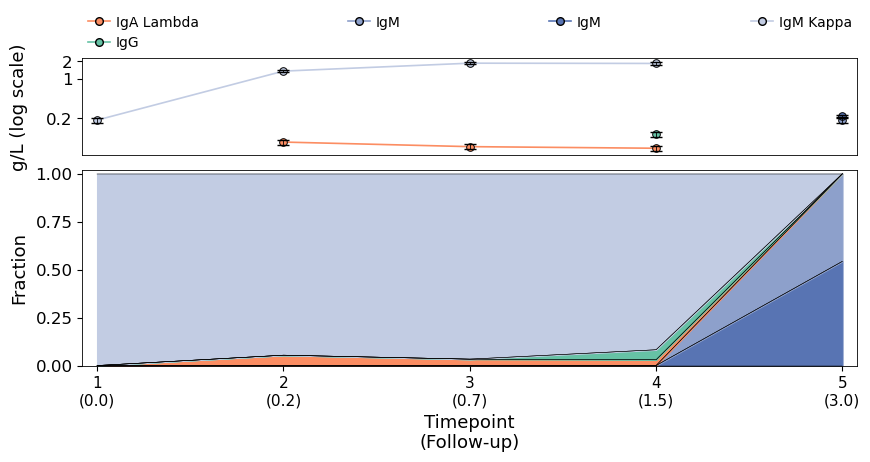

--- Generating Plot for PID: 1329 ---
{'1329_clone1': '#66c2a5', '1329_clone2': '#3f9d7f', '1329_clone3': '#9dd8c5', '1329_clone4': '#296653', '1329_clone5': '#d3eee5', '1329_clone6': '#133027'}


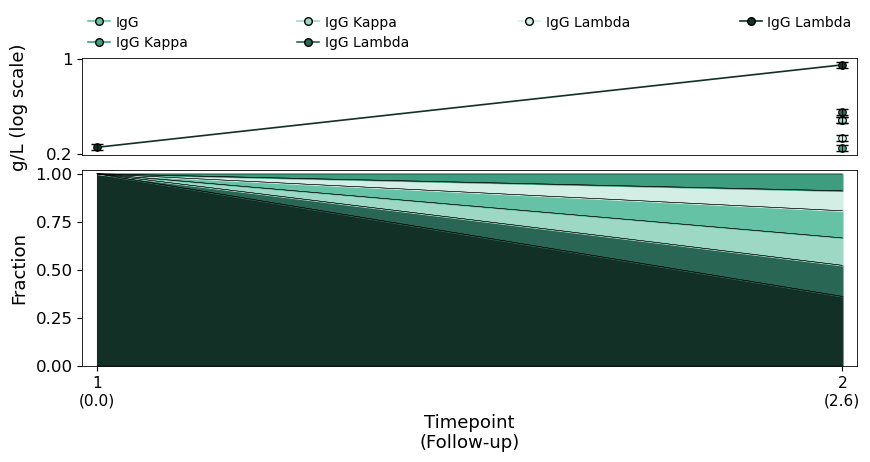

--- Generating Plot for PID: 2115 ---
{'2115_clone1': '#fc8d62', '2115_clone2': '#66c2a5', '2115_clone3': '#3f9d7f', '2115_clone4': '#9dd8c5', '2115_clone5': '#296653', '2115_clone6': '#d3eee5', '2115_clone7': '#133027'}


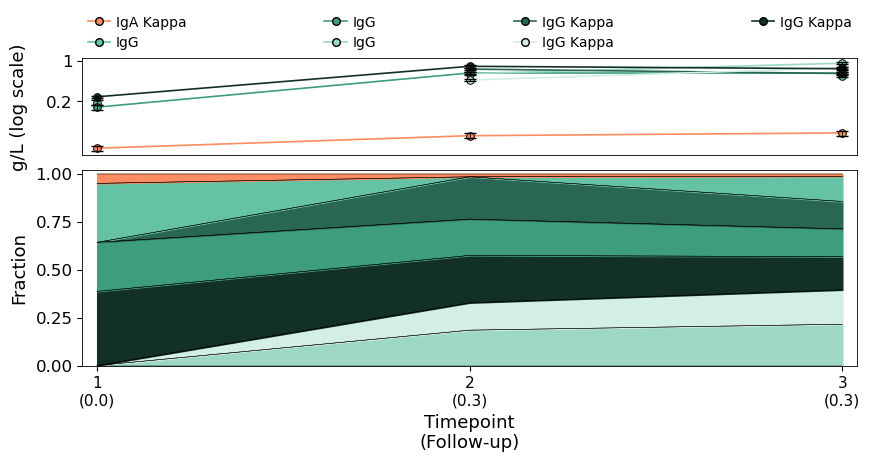

--- Generating Plot for PID: 2936 ---
{'2936_clone1': '#66c2a5', '2936_clone2': '#3f9d7f', '2936_clone3': '#8da0cb'}


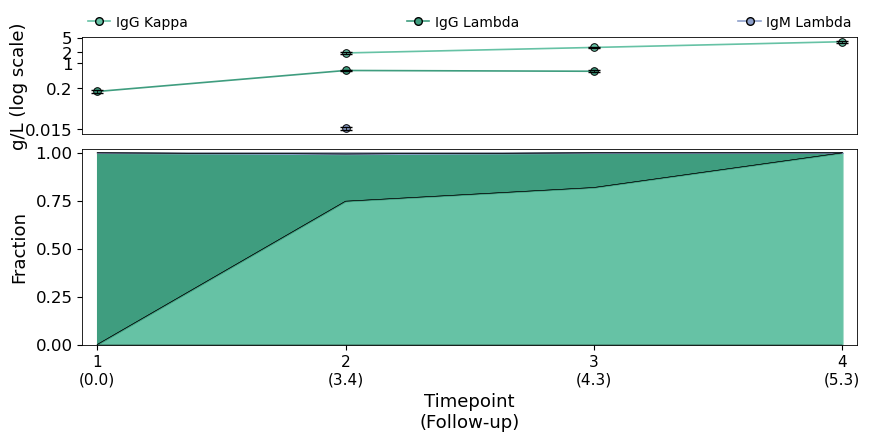

--- Generating Plot for PID: 1106 ---
{'1106_clone1': '#8da0cb', '1106_clone2': '#5874b3', '1106_clone3': '#c2cce3', '1106_clone4': '#3c5283', '1106_clone5': '#f6f8fb'}


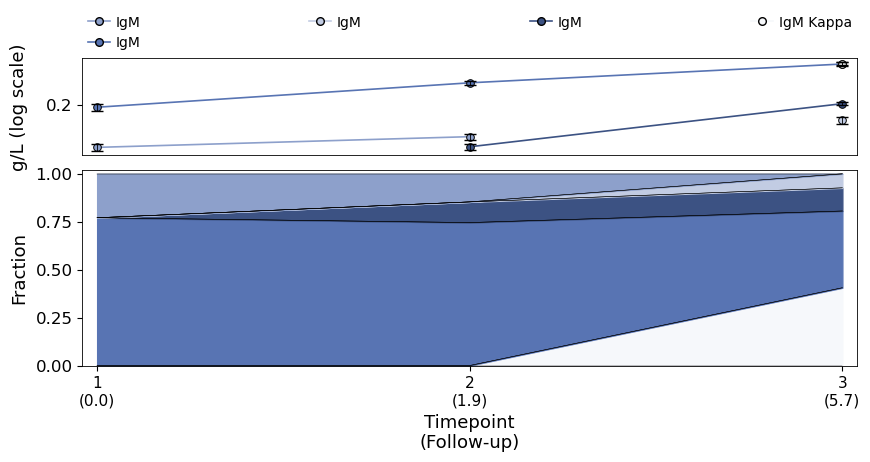

--- Generating Plot for PID: 1263 ---
{'1263_clone1': '#8da0cb', '1263_clone2': '#5874b3', '1263_clone3': '#c2cce3', '1263_clone4': '#3c5283', '1263_clone5': '#f6f8fb'}


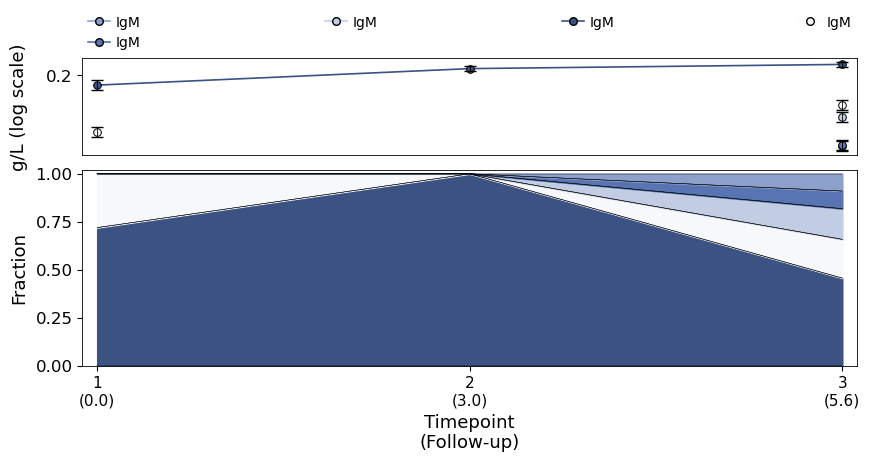

--- Generating Plot for PID: 2512 ---
{'2512_clone1': '#8da0cb', '2512_clone2': '#5874b3'}


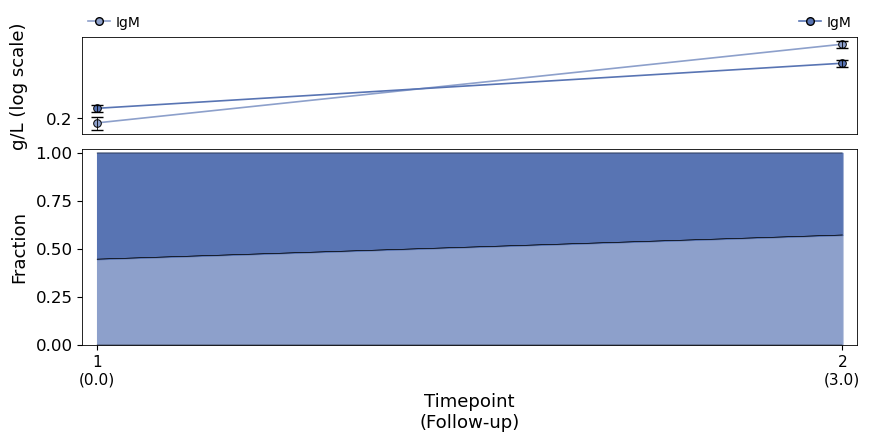

--- Generating Plot for PID: 6373 ---
{'6373_clone1': '#8da0cb', '6373_clone2': '#5874b3', '6373_clone3': '#c2cce3'}


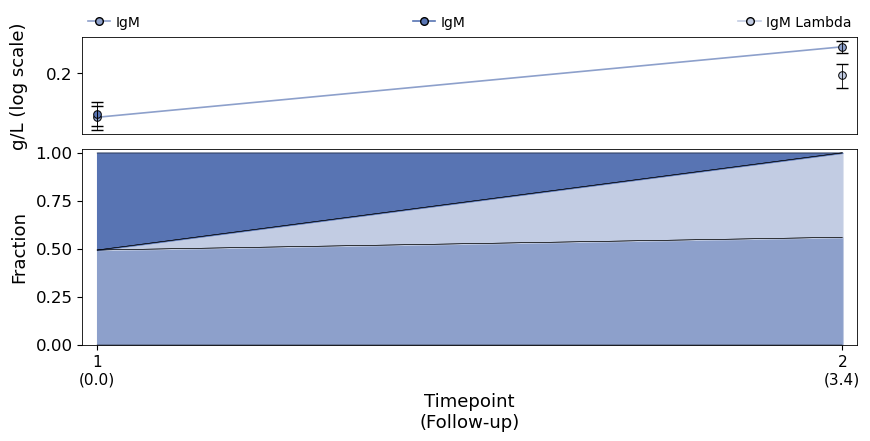

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb, to_hex
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter, NullLocator
import matplotlib.gridspec as gridspec
from collections import defaultdict
import colorsys
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# helper: palette
# -----------------------------
def generate_palette_from_base(base_color, n, delta=0.15):
    if n <= 1:
        return [base_color]

    base_rgb = to_rgb(base_color)
    h, l, s = colorsys.rgb_to_hls(*base_rgb)

    palette = [base_color]
    step = 1

    while len(palette) < n:
        if len(palette) < n:
            l_darker = max(0, l - delta * step)
            rgb = colorsys.hls_to_rgb(h, l_darker, s)
            palette.append(to_hex(rgb))

        if len(palette) < n:
            l_lighter = min(1, l + delta * step)
            rgb = colorsys.hls_to_rgb(h, l_lighter, s)
            palette.append(to_hex(rgb))

        step += 1

    return palette[:n]


# -----------------------------
# helper: clone label / color
# -----------------------------
def build_clone_color_maps(df):
    igh_colors = {
        'IgG': '#66c2a5',
        'IgA': '#fc8d62',
        'IgM': '#8da0cb',
    }

    clone_ids = sorted(df['clone_id'].dropna().unique())
    isotype_counts = defaultdict(int)
    clone_id_to_label = {}

    for clone_id in clone_ids:
        clone_data = df[df['clone_id'] == clone_id]
        unique_types = clone_data['Type'].dropna().unique()

        if len(unique_types) == 0:
            label = f"Unknown {clone_id}"
        else:
            label = " ".join(str(unique_types[0]).split("_"))

        clone_id_to_label[clone_id] = label
        iso = label.split()[0]
        isotype_counts[iso] += 1

    isotype_shades = {
        iso: generate_palette_from_base(base_color, isotype_counts[iso])
        for iso, base_color in igh_colors.items()
        if isotype_counts[iso] > 0
    }

    shade_indices = defaultdict(int)
    clone_id_to_color = {}

    for clone_id in clone_ids:
        label = clone_id_to_label[clone_id]
        iso = label.split()[0]

        if iso in isotype_shades:
            idx = shade_indices[iso]
            clone_id_to_color[clone_id] = isotype_shades[iso][idx]
            shade_indices[iso] += 1
        else:
            clone_id_to_color[clone_id] = "#999999"

    return clone_ids, clone_id_to_label, clone_id_to_color


# -----------------------------
# helper: one sample panel
# -----------------------------
def plot_one_sample(ax1, ax2, df_sample, sample_name, ticksize=12, innersize=13, titlesize=15):
    # remove non clones
    df_sample = df_sample[~df_sample['clone_id'].isna()].copy()
    df_sample = df_sample[~df_sample['Conc'].isna()].copy()

    if df_sample.empty:
        ax1.text(0.5, 0.5, f"{sample_name}\nNo valid clones",
                 ha="center", va="center", fontsize=titlesize)
        ax1.axis("off")
        ax2.axis("off")
        return

    df_sample["total_conc"] = df_sample.groupby(
        ["PROMISE_ID", "timepoint"]
    )["Conc"].transform("sum")
    df_sample["conc_fraction"] = df_sample["Conc"] / df_sample["total_conc"]

    clone_ids, clone_id_to_label, clone_id_to_color = build_clone_color_maps(df_sample)
    print(clone_id_to_color)

    # time order
    time_order_df = (
        df_sample[["timepoint", "yrs_from_baseline"]]
        .drop_duplicates()
        .sort_values("timepoint")
        .reset_index(drop=True)
    )
    timepoints = time_order_df["timepoint"].tolist()
    x_positions = np.arange(len(timepoints))

    # -------- upper plot: concentration --------
    legend_handles = []
    legend_labels = []

    for clone_id in clone_ids:
        sub = (
            df_sample[df_sample["clone_id"] == clone_id]
            .groupby("timepoint", as_index=False)
            .agg({
                "Conc": "first",
                "yrs_from_baseline": "first"
            })
            .set_index("timepoint")
            .reindex(timepoints)
            .reset_index()
        )

        y_vals = pd.to_numeric(sub["Conc"], errors="coerce").values.astype(float)

        y_plot = y_vals.copy()

        # small value for 0 in log scale
        valid_nonmissing = ~np.isnan(y_plot)
        y_plot[(valid_nonmissing) & (y_plot <= 0)] = 1e-4

        # 10% below 0.2g/L / 5% above 0.2g/L
        y_errs = np.full_like(y_plot, np.nan, dtype=float)
        present_mask = ~np.isnan(y_vals)
        y_errs[present_mask] = np.where(
            y_vals[present_mask] <= 0.2,
            y_vals[present_mask] * 0.10,
            y_vals[present_mask] * 0.05
        )

        color = clone_id_to_color[clone_id]
        label = clone_id_to_label[clone_id]

        ax1.plot(
            x_positions, y_plot,
            color=color,
            linestyle='-',
            linewidth=1.2,
            marker='o',
            markersize=5.5,
            markeredgewidth=0.7,
            markeredgecolor='black',
            zorder=2
        )

        # errorbar
        if present_mask.any():
            ax1.errorbar(
                x_positions[present_mask],
                y_plot[present_mask],
                yerr=y_errs[present_mask],
                fmt='none',
                ecolor='black',
                elinewidth=0.6,
                capsize=4,
                zorder=3
            )

        legend_handles.append(
            Line2D([0], [0],
                   color=color,
                   marker='o',
                   markerfacecolor=color,
                   markeredgecolor='black',
                   linewidth=1.2,
                   markersize=5.5)
        )
        legend_labels.append(label)

    ax1.set_xticks([])
    ax1.xaxis.set_visible(False)
    ax1.set_yscale('log')
    yticks = [0.015, 0.2, 1, 2, 5, 10]
    ax1.yaxis.set_major_locator(FixedLocator(yticks))
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
    ax1.yaxis.set_minor_locator(NullLocator())
    ax1.yaxis.set_minor_formatter(NullFormatter())
    ax1.tick_params(axis='y', labelsize=ticksize)
    ax1.set_ylabel("g/L (log scale)", fontsize=innersize, )

    n_legcol = min(len(legend_labels), 4) 

    ax1.legend(
        legend_handles,
        legend_labels,
        loc="lower left",
        bbox_to_anchor=(0, 1.02, 1, 0.2),   # ax1 right above
        mode="expand",                       
        ncol=n_legcol,
        fontsize=max(8, ticksize - 2),
        title=None,
        frameon=False,
        borderaxespad=0.0,
        handlelength=1.6,
        columnspacing=0.8,
        handletextpad=0.4
    )

    # -------- lower plot: stacked fraction --------
    stack_data = (
        df_sample.pivot_table(
            index="timepoint",
            columns="clone_id",
            values="conc_fraction",
            fill_value=0
        )
        .reindex(timepoints)
        .fillna(0)
    )

    if not stack_data.empty:
        ordered_cols = stack_data.iloc[-1].sort_values(ascending=False).index.tolist()
        stack_data = stack_data[ordered_cols]

        cum_data = stack_data.cumsum(axis=1)
        bottom_data = cum_data.shift(axis=1).fillna(0)

        for clone_id in stack_data.columns:
            color = clone_id_to_color[clone_id]

            ax2.fill_between(
                x_positions,
                bottom_data[clone_id].values,
                cum_data[clone_id].values,
                color=color
            )
            ax2.plot(
                x_positions,
                bottom_data[clone_id].values,
                color="black",
                linewidth=0.35,
                zorder=3
            )
            ax2.plot(
                x_positions,
                cum_data[clone_id].values,
                color="black",
                linewidth=0.35,
                zorder=3
            )

    xlabels = []
    yr_map = dict(zip(time_order_df["timepoint"], time_order_df["yrs_from_baseline"]))
    for tp in timepoints:
        yr = yr_map.get(tp, np.nan)
        if pd.isna(yr):
            xlabels.append(f"{tp}")
        else:
            xlabels.append(f"{tp}\n({yr:.1f})")

    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(xlabels, fontsize=ticksize - 1)
    ax2.set_ylim(0, 1.02)
    ax2.tick_params(axis='y', labelsize=ticksize)
    ax2.set_ylabel("Fraction", fontsize=innersize)

    ax2.set_xlabel("Timepoint\n(Follow-up)", fontsize=innersize)
    
    ## y-axis label position
    label_x_pos = -0.07  

    for ax in [ax1, ax2]:
        ax.margins(x=0.02)
        
        ax.yaxis.set_label_coords(label_x_pos, 0.5)
        
        for side, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_edgecolor("black")
            spine.set_linewidth(0.6)

# -----------------------------
# main plotting loop
# -----------------------------

ticksize = 17
outersize = 30
innersize = 24

########### Load data and execute the code ##########
filt_reshaped2 = pd.read_csv("../data/PROMISE_ms_clone.csv", sep=",")

### print table
#seq_list = [563, 1329, 2115, 2936, 1106, 1263, 2512, 6373]
clone_list = ['563_clone5', '1329_clone6', '2115_clone3', '2115_clone7', '2936_clone2', '1106_clone2', '1263_clone4', '2512_clone1', '6373_clone1']
df_filt = filt_reshaped2[filt_reshaped2['clone_id'].isin(clone_list)]
df_sorted = df_filt.sort_values(by=['PROMISE_ID', 'Sample_Date'], ascending=True)

agg_df = df_sorted.groupby('PROMISE_ID').agg({
    'Type': 'first',
    'm.z': 'median'
})

result_dict = agg_df.apply(lambda x: [x['Type'], x['m.z']], axis=1).to_dict()

### Draw
filt_reshaped2 = filt_reshaped2[filt_reshaped2['Mass_Spect_Diagnosis_SK_New'] != 'Negative']

### remove 1) Type = Lambda or Kappa & Conc = 0.0, 2) C1q-1 (artifact), <LLMI, MSL --> Negative
remove_type = filt_reshaped2['Type'].isin(['Lambda', 'Kappa'])
remove_flag = filt_reshaped2['Flag'].isin(['C1q-1', 'MSL', '<LLMI'])

filt_reshaped2_filtered = filt_reshaped2.loc[~(remove_type | remove_flag)].copy()

### remove negative
mask_all_negative = (
    filt_reshaped2_filtered
    .groupby('PROMISE_ID')['Mass_Spect_Diagnosis_SK_New']
    .transform(lambda x: (x == 'Negative').all())
)

filt_reshaped2_filtered = filt_reshaped2_filtered.loc[~mask_all_negative].copy()

sample_dict = {
    "PROMISE sequenced": [563, 1329, 2115, 2936, 1106, 1263, 2512, 6373],
}

for key, sample_list in sample_dict.items():
    for sample in sample_list:
        print(f"--- Generating Plot for PID: {sample} ---")
        
        fig = plt.figure(figsize=(10, 4)) 
        
        inner = gridspec.GridSpec(
            2, 1, 
            height_ratios=[1, 2], 
            hspace=0.1
        )

        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1], sharex=ax1)

        df_sample = filt_reshaped2_filtered[filt_reshaped2_filtered['PROMISE_ID'] == sample].copy()
        
        if df_sample.empty:
            print(f"Skipping {sample}: No data found.")
            plt.close(fig)
            continue
            
        plot_one_sample(ax1, ax2, df_sample, sample_name=sample)

        plt.tight_layout()
        
        save_name = f"../00.Figures/F1_plot_PROMISE_MGIP_to_MGUS_{sample}.pdf"
        plt.savefig(save_name, bbox_inches="tight")
        
        plt.show() 